# 01 — Análisis Exploratorio de Datos (EDA) y Clustering

Este notebook se enfoca en comprender los factores asociados a la retención y deserción estudiantil. A través de un Análisis Exploratorio de Datos (EDA) bivariado y multivariado, buscaremos responder interrogantes clave del negocio.

Finalmente, utilizaremos técnicas de Aprendizaje No Supervisado (K-Means) para agrupar a los estudiantes basándonos en su rendimiento y asistencia.

In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"
print(f"Proyecto: {PROJECT_ROOT}")

Proyecto: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe


## 1. Carga y Preparación Inicial

In [3]:
# Cargar datos
df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Crear columna auxiliar binaria para calcular tasas de deserción
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')
df['es_baja_retencion'] = (df['estado_matricula'] == 'BAJA_RETENCION').astype(int)

df.head(3)

Filas: 1298, Columnas: 17


,id_estudiante,nombre,rut,carrera,sede,año_ingreso,email,estado_matricula,id_inscripcion,codigo_asignatura,nombre_asignatura,seccion,semestre,año,docente,total_ausencias,promedio_notas,es_baja_retencion
0,1.0,Ignacio Espinoza Vergara,23003953-7,Enfermería,NaN,2020.0,ignacio.espinoza@outlook.com,REGULAR,899.0,ASG-127,Contabilidad,001D,2.0,2023.0,Felipe Tapia Aguilera,0.0,1.9,0
1,NaN,Carlos Gatica Medina,NaN,Administración,Santiago Centro,2023.0,carlos.gatica@outlook.com,REGULAR,5.0,ASG-374,Programación,002D,2.0,NaN,Tomás Muñoz Díaz,0.0,4.4,0
2,NaN,Carlos Gatica Medina,NaN,Administración,Santiago Centro,2023.0,carlos.gatica@outlook.com,REGULAR,83.0,ASG-455,Contabilidad,003D,1.0,NaN,Camila Torres Medina,1.0,2.7,0


## 2. Análisis Exploratorio de Datos (EDA)
A continuación, responderemos visualmente a las preguntas planteadas.

### Pregunta 1: ¿Cómo se distribuye la deserción según la Sede?

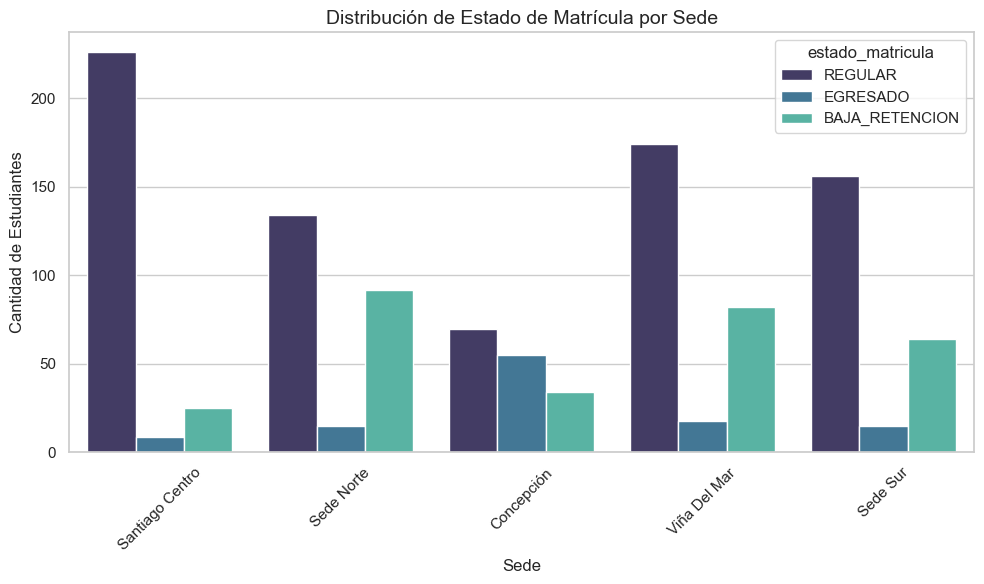

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df.dropna(subset=['sede', 'estado_matricula']),
    x='sede', 
    hue='estado_matricula',
    palette='mako'
)
plt.title('Distribución de Estado de Matrícula por Sede', fontsize=14)
plt.xlabel('Sede')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pregunta 2: ¿Cuál es la Tasa de Deserción según el Semestre?

[05/19/26 17:56:57] WARNING  /var/folders/sk/94kbw51x05s9z24_d_2ypn_r0000gn/T/ipykernel_9245/257024 ]8;id=15617703;file:///Users/unk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=15617704;file:///Users/unk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/warnings.py#112\112]8;;\
                             2428.py:3: FutureWarning:                                                             
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(                                                                        
                                                                                                                   

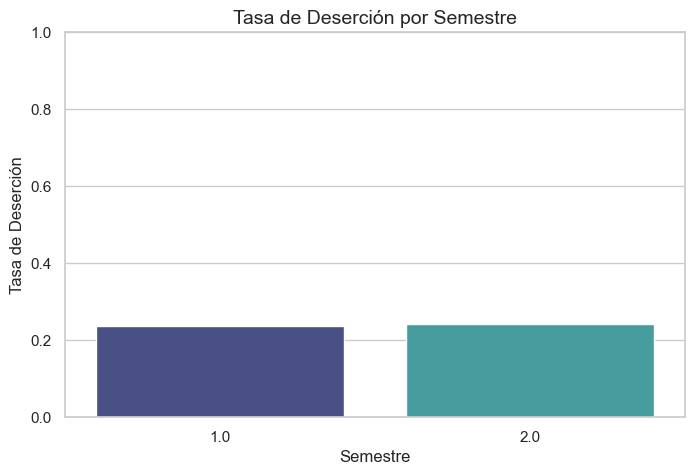

In [5]:
plt.figure(figsize=(8, 5))
# barplot calcula la media automáticamente (la proporción de 1s)
sns.barplot(
    data=df.dropna(subset=['semestre']),
    x='semestre',
    y='es_baja_retencion',
    palette='mako',
    errorbar=None
)
plt.title('Tasa de Deserción por Semestre', fontsize=14)
plt.xlabel('Semestre')
plt.ylabel('Tasa de Deserción')
plt.ylim(0, 1) # Escala de 0 a 100%
plt.show()

### Pregunta 3: ¿Cuál es la Tasa de Deserción según la Carrera?

                    WARNING  /var/folders/sk/94kbw51x05s9z24_d_2ypn_r0000gn/T/ipykernel_9245/583439 ]8;id=15617709;file:///Users/unk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=15617710;file:///Users/unk/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/warnings.py#112\112]8;;\
                             270.py:2: FutureWarning:                                                              
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `y` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               sns.barplot(                                                                        
                                                                                                                   

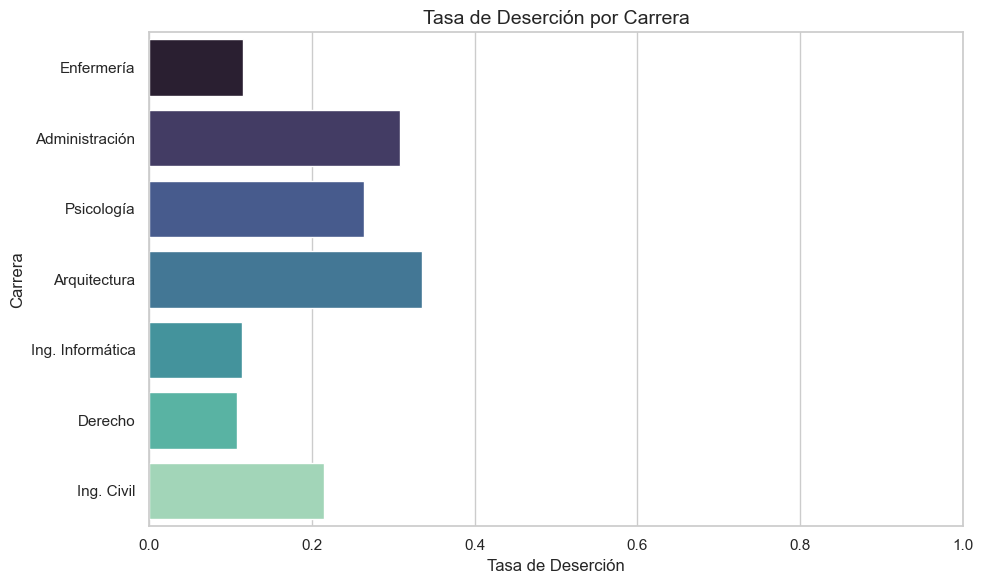

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df.dropna(subset=['carrera']),
    y='carrera',
    x='es_baja_retencion',
    palette='mako',
    errorbar=None,
    orient='h'
)
plt.title('Tasa de Deserción por Carrera', fontsize=14)
plt.xlabel('Tasa de Deserción')
plt.ylabel('Carrera')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 3. Aprendizaje No Supervisado: Clustering K-Means
Realizamos una segmentación de estudiantes basándonos puramente en sus resultados académicos.

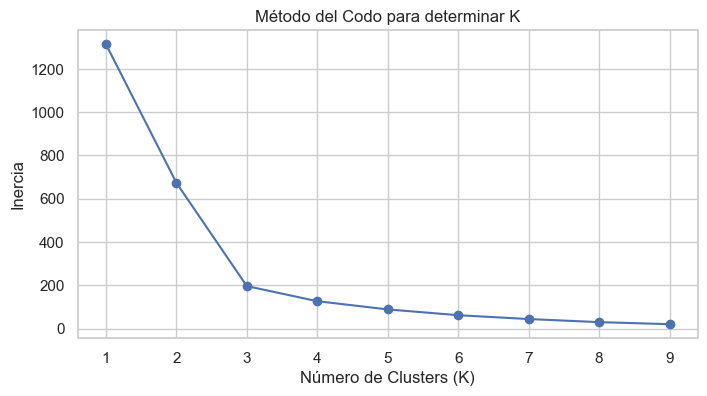

In [7]:
# Preprocesamiento para clustering (Solo variables numéricas continuas)
cluster_cols = ['total_ausencias', 'promedio_notas']
df_cluster = df.dropna(subset=cluster_cols).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[cluster_cols])

# Encontrar K óptimo con el Método del Codo
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo para determinar K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.show()

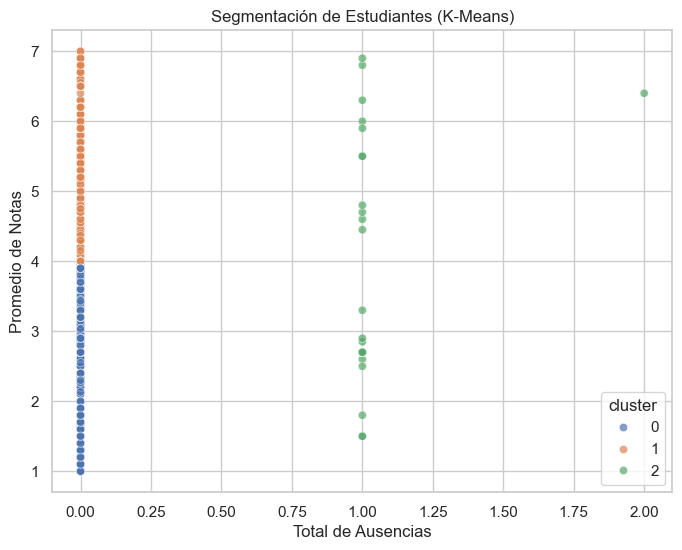

In [8]:
# Implementar K-Means con K=3 (ejemplo de agrupación visualmente coherente)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_cluster,
    x='total_ausencias',
    y='promedio_notas',
    hue='cluster',
    palette='deep',
    alpha=0.7
)
plt.title('Segmentación de Estudiantes (K-Means)')
plt.xlabel('Total de Ausencias')
plt.ylabel('Promedio de Notas')
plt.show()